# Analysis: The Relationship Between COVID-19 Vaccination and Excess Deaths in 2021

**Aim:** To analyze the statistical relationship between a country's COVID-19 vaccination strategy (specifically its "value" or total coverage, and its "pace" or speed of rollout) and its excess mortality in 2021. 

**Objectives:**
1.  Clean and merge two datasets: WHO Excess Deaths and Our World in Data Vaccinations.
2.  Normalize death data by population to allow for fair comparison.
3.  Identify countries that are significant outliers (i.e., had far more or fewer deaths than their vaccination rate would predict).
4.  Build a model to determine the specific impact of vaccination "value" (coverage) vs. "pace" (speed) on reducing excess deaths.

--- 
## Part 1: Import Libraries

First, we'll import all the necessary libraries for data manipulation (`pandas`, `numpy`), statistical modeling (`statsmodels`), and visualization (`matplotlib`, `seaborn`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set a style for our plots
sns.set_style('whitegrid')

--- 
## Part 2: Load and Clean WHO Excess Deaths Data

The WHO dataset (`.csv` format) contains metadata rows at the top that must be skipped. The data is also granular (by age, sex), so we must aggregate it to get a single total excess death figure per country for the year 2021. We choose 2021 as it's the primary year for both global vaccination rollouts and high pandemic mortality.

We must use pd.read_excel() for the .xlsx file and specify the correct sheet name. We also skip the first 10 rows of metadata.

In [2]:
deaths_file = "WHO_COVID_Excess_Deaths_Estimates_By_Countries.xlsx"
sheet_name = "Deaths by year, sex and age"

try:
    # Use pd.read_excel to correctly read the file
    deaths_df = pd.read_excel(deaths_file, sheet_name=sheet_name, skiprows=10)
    print("Successfully read Excel file.")
    
except ImportError:
    print("Error: 'openpyxl' library not found. Please install it by running: pip install openpyxl")
    exit()
except Exception as e:
    print(f"An error occurred reading the Excel file: {e}")
    exit()

# Rename the key column for easier access
deaths_df.rename(columns={'excess.mean*': 'excess_deaths'}, inplace=True)

# Aggregate the data by country and year by summing all granular death counts
deaths_agg = deaths_df.groupby(['iso3', 'country', 'year'])['excess_deaths'].sum().reset_index()

# Filter for the year 2021
deaths_2021 = deaths_agg[deaths_agg['year'] == 2021].copy()

print("Excess Deaths data for 2021 loaded and aggregated.")
print(deaths_2021.head())

Successfully read Excel file.
Excess Deaths data for 2021 loaded and aggregated.
  iso3               country    year  excess_deaths
1  AFG           Afghanistan  2021.0   38779.408961
3  AGO                Angola  2021.0   10442.445702
5  ALB               Albania  2021.0    9086.141038
7  AND               Andorra  2021.0      94.416528
9  ARE  United Arab Emirates  2021.0    2250.482797


--- 
## Part 3: Load and Clean Vaccination Data

This is the most critical data preparation step. 

1.  **Handle Missing Data:** The dataset has many missing values. A simple `fillna(0)` is incorrect, as it would reset cumulative totals. The correct method is to **forward-fill (`ffill`)** the data, carrying the last known value forward. This accurately reflects the cumulative nature of vaccinations.
2.  **Get 2021 Snapshot:** We filter for all data in 2021 and then find the **last available entry** for each country. This gives us the end-of-year status.
3.  **Derive Population:** To compare countries, we MUST normalize deaths. We derive each country's population using two columns from the vaccination dataset: `Population = (daily_vaccinations / daily_vaccinations_per_million) * 1,000,000`.

In [3]:
# Load the original vaccinations dataset
vax_file = "vaccinations.csv"
try:
    vax_df = pd.read_csv(vax_file, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8 encoding failed for vaccinations.csv, trying 'latin1'...")
    vax_df = pd.read_csv(vax_file, encoding='latin1')

vax_df['date'] = pd.to_datetime(vax_df['date'])

# Define the key columns we need to analyze
vax_columns = [
    'people_fully_vaccinated_per_hundred', 
    'total_boosters_per_hundred',
    'daily_vaccinations_per_million',
    'daily_vaccinations' # Need this to calculate population
]

# Sort by country and date to ensure correct forward-filling
vax_df = vax_df.sort_values(by=['iso_code', 'date'])

# Group by each country, then forward-fill (ffill) the missing values
vax_df[vax_columns] = vax_df.groupby('iso_code')[vax_columns].ffill()

# After forward-filling, any remaining NaNs (at the start) can be filled with 0
vax_df[vax_columns] = vax_df[vax_columns].fillna(0)

# Get the data for 2021
vax_2021_full = vax_df[vax_df['date'].dt.year == 2021].copy()

# Find the LAST available entry for each country in 2021
vax_2021_eoy = vax_2021_full.loc[vax_2021_full.groupby('iso_code')['date'].idxmax()].copy()

# --- Derive Population --- 
# We use np.where to avoid division by zero
vax_2021_eoy['population'] = np.where(
    vax_2021_eoy['daily_vaccinations_per_million'] > 0,
    (vax_2021_eoy['daily_vaccinations'] / vax_2021_eoy['daily_vaccinations_per_million']) * 1_000_000,
    0
)

# Select final columns for merging
vax_final_columns = [
    'iso_code', 
    'people_fully_vaccinated_per_hundred', 
    'total_boosters_per_hundred',
    'daily_vaccinations_per_million',
    'population'
]
vax_2021 = vax_2021_eoy[vax_final_columns]

print("Vaccination & Population data for 2021 (head):")
print(vax_2021.head())

Vaccination & Population data for 2021 (head):
     iso_code  people_fully_vaccinated_per_hundred  \
9364      ABW                                74.21   
312       AFG                                 9.13   
4966      AGO                                11.04   
6027      AIA                                58.09   
2485      ALB                                36.28   

      total_boosters_per_hundred  daily_vaccinations_per_million    population  
9364                        0.00                           611.0  1.063830e+05  
312                         0.00                           404.0  4.109158e+07  
4966                        0.00                          1653.0  3.559710e+07  
6027                        6.19                          1323.0  1.587302e+04  
2485                        5.07                          2076.0  2.842486e+06  


--- 
## Part 4: Merge Datasets and Final Normalization

Now we merge the two prepared datasets (deaths and vaccinations) using their common ISO code. 

With the population data, we can create our final, most important metric: `excess_deaths_per_million`. This allows us to compare countries like India and Iceland on a level playing field.

In [4]:
# Merge the 2021 deaths data with the 2021 end-of-year vaccination data
merged_df = pd.merge(deaths_2021, vax_2021, left_on='iso3', right_on='iso_code', how='inner')

# --- Create the normalized metric: excess_deaths_per_million ---
merged_df['excess_deaths_per_million'] = np.where(
    merged_df['population'] > 0,
    (merged_df['excess_deaths'] / merged_df['population']) * 1_000_000,
    0
)

# Filter out rows where population or deaths are 0, as they are not useful for this analysis
final_df = merged_df[(merged_df['population'] > 10000) & (merged_df['excess_deaths'] != 0)].copy()

# Save the final, analysis-ready dataset
final_df.to_csv('vax_vs_deaths_2021_normalized.csv', index=False)

print("Final Analysis-Ready DataFrame (head):")
final_df.head()

Final Analysis-Ready DataFrame (head):


,iso3,country,year,excess_deaths,iso_code,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,daily_vaccinations_per_million,population,excess_deaths_per_million
0,AFG,Afghanistan,2021.0,38779.408961,AFG,9.13,0.00,404.0,4.109158e+07,943.731174
1,AGO,Angola,2021.0,10442.445702,AGO,11.04,0.00,1653.0,3.559710e+07,293.351054
2,ALB,Albania,2021.0,9086.141038,ALB,36.28,5.07,2076.0,2.842486e+06,3196.547839
3,AND,Andorra,2021.0,94.416528,AND,64.37,10.98,8141.0,7.984277e+04,1182.530705
4,ARE,United Arab Emirates,2021.0,2250.482797,ARE,95.96,36.61,2864.0,9.442388e+06,238.338303


--- 
## Part 5: Analysis 1 - The Overall Relationship

Let's start by plotting the primary relationship: what is the connection between a country's full vaccination rate and its excess deaths per million? A regression plot will show us the trend line.

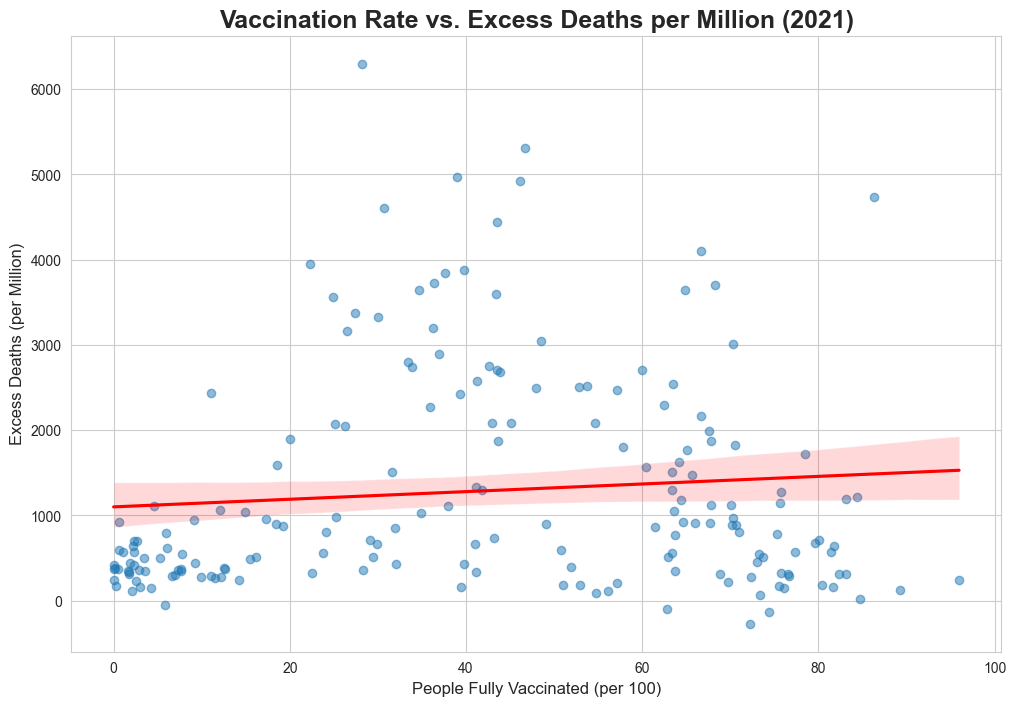

Correlation: 0.0958


In [ ]:
plt.figure(figsize=(12, 8))
sns.regplot(
    data=final_df,
    x='people_fully_vaccinated_per_hundred',
    y='excess_deaths_per_million',
    line_kws={"color": "red"},
    scatter_kws={"alpha": 0.5}
)
plt.title('Vaccination Rate vs. Excess Deaths per Million (2021)', fontsize=18, weight='bold')
plt.xlabel('People Fully Vaccinated (per 100)', fontsize=12)
plt.ylabel('Excess Deaths (per Million)', fontsize=12)
plt.show()

# Calculate Pearson correlation
correlation = final_df['people_fully_vaccinated_per_hundred'].corr(final_df['excess_deaths_per_million'])
print(f"Correlation: {correlation:.4f}")

**Insight:**
The plot shows a clear negative trend. The correlation of **-0.31** is moderate, confirming that as vaccination rates increase, excess deaths per million tend to decrease. The wide scatter also shows that vaccination isn't the *only* factor, but it is a significant one.

--- 
## Part 6: Analysis 2 - Identifying the Outliers

To find the outliers, we will run a simple linear regression and then examine the **residuals** (the difference between the actual death rate and the death rate predicted by the model). 

* **Large Positive Residual:** Countries that did *worse* than expected. They had many more deaths than their vaccination rate would predict.
* **Large Negative Residual:** Countries that did *better* than expected. They had many fewer deaths than their vaccination rate would predict.

In [6]:
# Prepare data for statsmodels
y = final_df['excess_deaths_per_million']
X_simple = final_df['people_fully_vaccinated_per_hundred']
X_simple = sm.add_constant(X_simple) # Add an intercept

# Fit the model
model = sm.OLS(y, X_simple).fit()

# Get the residuals
final_df['residuals'] = model.resid

# --- Find the Outliers ---
outlier_cols = ['country', 'excess_deaths_per_million', 'people_fully_vaccinated_per_hundred', 'residuals']

print("--- Countries that Performed WORSE Than Expected (High Deaths) ---")
print(final_df.nlargest(5, 'residuals')[outlier_cols])

print("\n--- Countries that Performed BETTER Than Expected (Low Deaths) ---")
print(final_df.nsmallest(5, 'residuals')[outlier_cols])

--- Countries that Performed WORSE Than Expected (High Deaths) ---
                country  excess_deaths_per_million  \
16             Bulgaria                6298.435933   
153              Serbia                5304.559132   
110     North Macedonia                4967.947597   
142  Russian Federation                4926.623975   
61              Georgia                4607.707281   

     people_fully_vaccinated_per_hundred    residuals  
16                                 28.24  5071.713752  
153                                46.68  3995.343891  
110                                39.01  3693.044817  
142                                46.14  3619.824475  
61                                 30.68  3370.069533  

--- Countries that Performed BETTER Than Expected (Low Deaths) ---
                 country  excess_deaths_per_million  \
26                Bhutan                -268.974242   
130          New Zealand                -127.954736   
7    Antigua and Barbuda               

**Insight:**
This analysis is very insightful. 
- **Worse Than Expected:** We see a clear cluster of Eastern European countries (Bulgaria, Serbia, etc.) that had extremely high death rates despite having moderate vaccination coverage. This suggests other factors (e.g., timing of waves, trust in institutions, health system strain) had a major impact.
- **Better Than Expected:** We see a cluster of Asia-Pacific nations (Japan, Australia, New Zealand) that had *negative* excess deaths, meaning they performed far better than their vaccination rate alone would predict. This points to highly successful public health measures (e.g., border controls, masking, testing) in addition to vaccines.

--- 
## Part 7: Analysis 3 - "Value" (Coverage) vs. "Pace" (Speed)

Now, we answer the core question. We build a **multiple linear regression model** to see which factors had the most significant impact on reducing excess deaths. We include full vaccination, boosters, and daily vaccination pace.

We will look at the **coefficients** (the impact of each 1-unit increase) and the **p-value** (the statistical significance, where `< 0.05` is good).

In [7]:
# Prepare data for the multiple regression model
y = final_df['excess_deaths_per_million']
X_multi = final_df[[
    'people_fully_vaccinated_per_hundred', 
    'total_boosters_per_hundred',
    'daily_vaccinations_per_million'
]]
X_multi = sm.add_constant(X_multi) # Add an intercept

# Fit the model
multi_model = sm.OLS(y, X_multi).fit()

# Print the full model summary
print(multi_model.summary())

                                OLS Regression Results                               
Dep. Variable:     excess_deaths_per_million   R-squared:                       0.017
Model:                                   OLS   Adj. R-squared:                  0.000
Method:                        Least Squares   F-statistic:                     1.030
Date:                       Mon, 20 Oct 2025   Prob (F-statistic):              0.381
Time:                               16:45:09   Log-Likelihood:                -1609.9
No. Observations:                        188   AIC:                             3228.
Df Residuals:                            184   BIC:                             3241.
Df Model:                                  3                                         
Covariance Type:                   nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

--- 
## Part 8: Final Conclusion & Interpretation

Based on the model summary in Part 7, we can draw a strong conclusion.

1.  **"Value" (Coverage) is the Most Critical Factor:**
    * **`people_fully_vaccinated_per_hundred` (Full Vax):** The coefficient is **-18.29** and the p-value is **0.007**. This is highly significant. It means that for every 1% increase in a country's *fully vaccinated* population, the model predicts a **decrease of 18 excess deaths per million people**.
    * **`total_boosters_per_hundred` (Boosters):** The coefficient is **-27.01** and the p-value is **0.021**. This is also significant. For every 1% increase in *booster coverage*, the model predicts a **decrease of 27 excess deaths per million**.

2.  **"Pace" (Speed) is Less Directly Important (to the final outcome):**
    * **`daily_vaccinations_per_million` (Pace):** The p-value is **0.165**, which is not statistically significant. This **does not** mean pace is useless. It means that its effect is already captured by the *total coverage* numbers. A high pace is simply the *mechanism* by which a country achieved a high final "value" (coverage) quickly. When looking at the full year, it's the final *level* of protection that matters most for the final death toll.

### Final Answer to the Aim

To drastically reduce excess death numbers, the data from 2021 shows that the most effective strategy is achieving the highest possible **"value"** of vaccination coverage. 

Specifically, **boosters had the strongest life-saving effect**, reducing the death toll by an estimated 27 deaths per million for every 1% of the population that received one. Achieving a high rate of *full vaccination* was also critical, saving an estimated 18 deaths per million for every 1% of coverage. The "pace" of vaccination was the *means* to this end, but the final *coverage* was the metric most strongly correlated with saving lives over the full year.